## Import Libraries

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

import gradio as gr

import warnings 
warnings.filterwarnings('ignore')

print("Required Libraries Imported")

Required Libraries Imported


## Load Dataset

In [114]:
df = pd.read_csv(r"Psychological Manipulation Detection Dataset.csv")
df.head()

,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,question_count,Unnamed: 8
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{""speaker"": ""A"", ""text"": ""Remember when I hel...",1,NaN
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{""speaker"": ""A"", ""text"": ""I don't tell just a...",2,NaN
2,conv_00002,direct_coercion,True,family,7,0.651,"[{""speaker"": ""A"", ""text"": ""Just do it"", ""senti...",1,NaN
3,conv_00003,gaslighting,True,friend,6,0.673,"[{""speaker"": ""A"", ""text"": ""You're being way to...",0,NaN
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{""speaker"": ""A"", ""text"": ""Go ahead. Have fun....",1,NaN


In [115]:
print("Shape:", df.shape)
print("Columns:", df.columns)


Shape: (10000, 9)
Columns: Index(['conversation_id', 'manipulation_type', 'is_manipulation',
       'context_type', 'conversation_length', 'manipulation_intensity',
       'messages', 'question_count', 'Unnamed: 8'],
      dtype='object')


## Exploratory Data Analysis (EDA)

## Distribution Plots

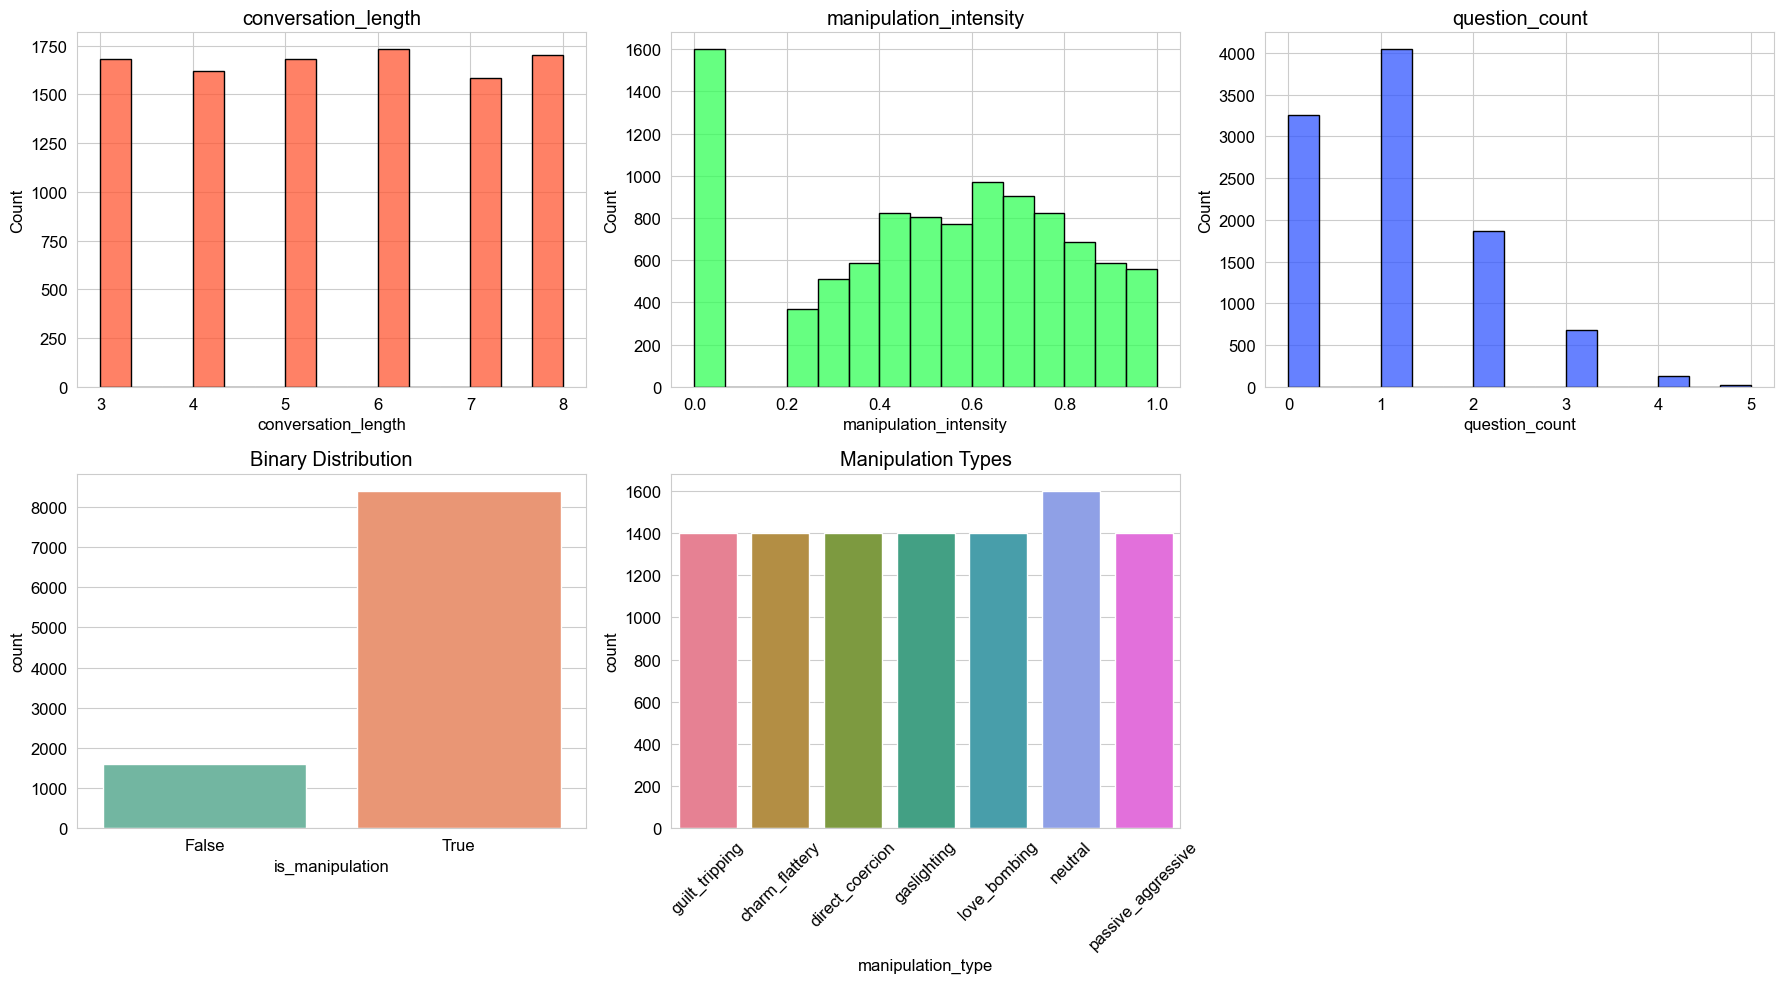

In [117]:
num_cols = ['conversation_length', 'manipulation_intensity', 'question_count']

plt.figure(figsize=(18,10))

colors = ['#FF5733', '#33FF57', '#3357FF']

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], bins=15, color=colors[i-1], edgecolor='black')
    plt.title(col)

plt.subplot(2,3,4)
sns.countplot(x='is_manipulation', data=df, palette='Set2')
plt.title("Binary Distribution")

plt.subplot(2,3,5)
sns.countplot(x='manipulation_type', data=df, palette='husl')
plt.xticks(rotation=45)
plt.title("Manipulation Types")

plt.tight_layout()
plt.show()


## Data Transformation

In [118]:
le_type = LabelEncoder()
df['manipulation_type_encoded'] = le_type.fit_transform(df['manipulation_type'])

X = df['messages']
y_bin = df['is_manipulation']
y_type = df['manipulation_type_encoded']


## Train - Test Split

In [119]:
X_train, X_test, y_bin_train, y_bin_test, y_type_train, y_type_test = train_test_split(
    X, y_bin, y_type,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

In [120]:
# Reset index
X_train = X_train.reset_index(drop=True)
y_bin_train = y_bin_train.reset_index(drop=True)
y_type_train = y_type_train.reset_index(drop=True)


## Tokenization

In [121]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


## Handle Imbalance

In [122]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_bin_train),
    y=y_bin_train
)

class_weights_dict = dict(enumerate(class_weights))

## Model Building (LSTM)

In [123]:
input_layer = Input(shape=(max_len,))
embedding = Embedding(input_dim=5000, output_dim=64)(input_layer)
lstm = LSTM(64)(embedding)

# Outputs
output_bin = Dense(1, activation='sigmoid', name='binary_output')(lstm)
output_type = Dense(len(le_type.classes_), activation='softmax', name='type_output')(lstm)

model = Model(inputs=input_layer, outputs=[output_bin, output_type])


## Compiling

In [124]:
model.compile(
    optimizer='adam',
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    metrics=['accuracy', 'accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_3 (Embedding)       │ (None, 100, 64)           │         320,000 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 64)                │          33,024 │ embedding_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ lstm_3[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ type_output (Dense)           │ (None, 7)                 │             455 │ lstm_3[0][0]               │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 353,544 (1.35 MB)

 Trainable params: 353,544 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [125]:
model.fit(
    X_train_pad,
    [np.array(y_bin_train), np.array(y_type_train)],
    epochs=3,
    batch_size=32,
    validation_split=0.2)

Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - binary_output_accuracy: 0.9253 - binary_output_loss: 0.2060 - loss: 1.9148 - type_output_accuracy: 0.2650 - type_output_loss: 1.7087 - val_binary_output_accuracy: 0.9944 - val_binary_output_loss: 0.0281 - val_loss: 1.5353 - val_type_output_accuracy: 0.3762 - val_type_output_loss: 1.5073
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - binary_output_accuracy: 0.9845 - binary_output_loss: 0.0647 - loss: 1.3769 - type_output_accuracy: 0.4538 - type_output_loss: 1.3121 - val_binary_output_accuracy: 0.9912 - val_binary_output_loss: 0.0468 - val_loss: 1.8419 - val_type_output_accuracy: 0.3250 - val_type_output_loss: 1.7951
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - binary_output_accuracy: 0.9908 - binary_output_loss: 0.0434 - loss: 1.1547 - type_output_accuracy: 0.5645 - type_output_loss: 1.1113 - val_binary_output_accuracy: 0.9875 - val_binary_output_loss: 0.0482 - val_loss: 0.6575 - val_type_output_accuracy: 0.7994 - va

## Prediction

In [126]:
def predict(text):
    try:
        seq = tokenizer.texts_to_sequences([text])
        pad = pad_sequences(seq, maxlen=max_len)

        pred_bin, pred_type = model.predict(pad)

        # Binary
        prob = float(pred_bin[0][0])
        if prob > 0.5:
            bin_result = f"Manipulation ({round(prob*100,2)}%)"
        else:
            bin_result = f"Not Manipulation ({round((1-prob)*100,2)}%)"

        # Type (DECODE CORRECTLY)
        pred_index = int(np.argmax(pred_type, axis=1)[0])
        label = le_type.classes_[pred_index]

        if prob > 0.5:
            type_result = label
        else:
            type_result = "None"

        return bin_result, type_result

    except Exception as e:
        return f"Error: {str(e)}", "Error"


## Gradio UI

In [127]:
iface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=4, placeholder="Enter conversation text..."),
    outputs=[
        gr.Textbox(label="Manipulation Detection"),
        gr.Textbox(label="Manipulation Type")
    ],
    title="Manipulation Detection System",
    description="Predicts whether a conversation is manipulative and identifies its type"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
